## Análisis Descriptivo

### Módulos necesarios para la carga y visualización de datos

In [77]:
import polars as pl
from plotnine import aes, geom_bar, coord_flip, geom_histogram, geom_point, ggplot, scale_x_continuous, labs, theme_bw, theme, element_text, element_blank, element_rect, facet_wrap, geom_density
import pyprojroot
# ACORDARNOS DE AGREGAR A LAS DEPENDENCIAS pyarrow y la que no estaba en el tp1
ROOT = pyprojroot.here()

### Carga de Datos

In [78]:
datos_temporada1 = pl.read_parquet(ROOT / "Datos" / "temporada1.parquet")

In [79]:
datos_temporada1.null_count()

pitch_id,release_speed,batter,pitcher,description,stand,p_throws,pitch_type,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1381,367,0,0,0,0,0,367,0,0,3033,1060,367,400,367,412


Las variables que presentan valores faltantes son: 
* Identificador único del pitcheo
* Velocidad del pitcheo
* Tipo de pitcheo
* Movimiento horizontal desde la perspectiva del catcher (en pies)
* Movimiento vertical, en pies, desde la perspectiva del catcher
* Posición horizontal de la pelota cuando cruza el home plate, desde la perspectiva del catcher.
* Posición vertical de la pelota cuando cruza el home plate, desde la perspectiva del catcher.
* Límite superior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate.
* Límite inferior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate.

Los borramos, el tamaño muestral es grande.

In [80]:
datos_temporada1 = datos_temporada1.drop_nulls()

In [81]:
datos_temporada1.describe()

statistic,pitch_id,release_speed,batter,pitcher,description,stand,p_throws,pitch_type,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",704721.0,704721.0,704721.0,704721.0,"""704721""","""704721""","""704721""","""704721""",704721.0,704721.0,704721.0,704721.0,704721.0,704721.0,704721.0,704721.0
"""null_count""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.3552e6,88.852346,5787.098877,5793.444164,null,null,null,null,0.883687,0.895208,-0.103943,0.657107,0.044413,2.275039,3.391942,1.573853
"""std""",204933.892232,6.043039,521.421304,525.80555,null,null,null,null,0.968484,0.828375,0.866665,0.747542,0.845991,0.984611,0.164628,0.089671
"""min""",2.000001e6,30.1,5001.0,5003.0,"""ball""","""L""","""L""","""CH""",0.0,0.0,-2.56,-2.13,-6.1,-5.07,2.5,0.77
"""25%""",2.177411e6,84.599998,5334.0,5351.0,null,null,null,null,0.0,0.0,-0.83,0.2,-0.53,1.64,3.3,1.51
"""50%""",2.355343e6,89.900002,5720.0,5728.0,null,null,null,null,1.0,1.0,-0.17,0.76,0.04,2.28,3.41,1.56
"""75%""",2.532745e6,93.699997,6177.0,6176.0,null,null,null,null,2.0,2.0,0.59,1.28,0.62,2.92,3.49,1.62
"""max""",2.709852e6,103.400002,7100.0,7100.0,"""swinging_strike_blocked""","""R""","""R""","""SV""",4.0,2.0,2.84,2.58,9.11,9.39,4.47,2.26


### Análisis Univariado

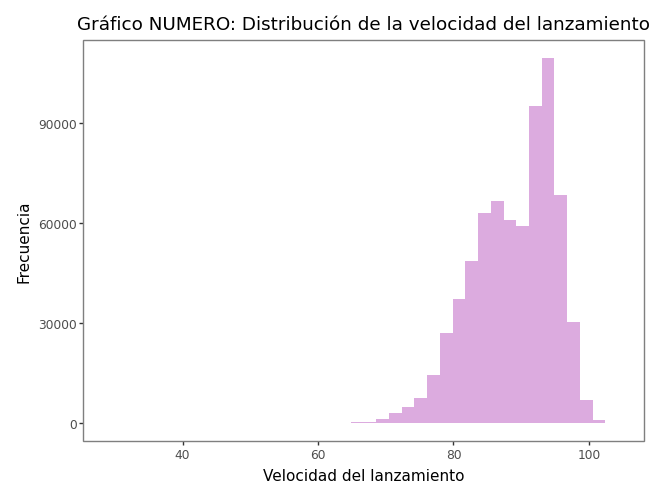

In [82]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "release_speed"),
                        bins = 40, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Velocidad del lanzamiento",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Distribución de la velocidad del lanzamiento"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

Media = 88.85. Asimétrica a la derecha. con valores extremos en valores chicos

In [83]:
datos_temporada1["description"].value_counts()

description,count
str,u32
"""bunt_foul_tip""",41
"""hit_by_pitch""",2099
"""swinging_strike_blocked""",4682
"""foul""",125096
"""ball""",235123
…,…
"""pitchout""",33
"""blocked_ball""",17187
"""missed_bunt""",360


A partir de la variable description, que indica el resultado de cada *pitch*, se construyó una nueva variable que identifica si el bateador realizó un *swing* o no.

En *baseball*, luego de que el *pitcher* realiza un *pitch*, el bateador puede optar por intentar golpear la pelota o dejar pasar el lanzamiento.

**Situaciones en la que el bateador realiza un *swing***
* *hit into play*: el bateador golpea la pelota y esta entra dentro del territorio válido de juego.
* *foul*: el bateador golpea la pelota, pero esta cae en territorio inválido.
    * *foul tip*: el bateador logra golpear la pelota y el *catcher* la atrapa directamente.
    * *foul pitchout*: ocurre cuando el lanzamiento fue un *pitchout* (estrategia defensiva por parte del *pitcher*) y el bateador realiza un *swing* que provoca que la pelota caiga en territorio inválido.
* *swinging strike*: el bateador intenta golpear la pelota pero falla, recibiendo un *strike*.
    * *swinging strike blocked*: variante de *swinging strike* en la que el *catcher* debe bloquear la pelota.
* *missed bunt*: el bateador intenta realizar un *bunt* (golpear levemente la pelota de manera que esta quede en una distancia corta) pero no logra tocar la pelota, resultando en un strike.
* *bunt foul tip*: el bateador intenta un *bunt* y produce un *foul tip*.
* *foul bunt*: el bateador realiza un *bunt* y la pelota cae en territorio inválido.

**Situaciones en las que el bateador no realiza un *swing***
* *pitchout*: como estrategia defensiva, el *pitcher* lanza la pelota fuera de la zona de *strike* y no hay intento de bateo por parte del bateador.
* *ball*: lanzamiento fuera de la zona de *strike* que el bateador deja pasar.
* *called strike*: lanzamiento dentro de la zona de *strike* que el bateador no intenta golpear, resultando en un *strike*.
* *hit by pitch*: la pelota golpea al bateador.
* *blocked ball*: la pelota rebota en el suelo, sin que el bateador intente batear.

In [84]:
datos_temporada1 = datos_temporada1.with_columns(
    pl.when(pl.col("description").is_in(["hit_into_play", 
                                        "foul",
                                        "foul_tip",
                                        "foul_pitchout",
                                        "swinging_strike",
                                        "swinging_strike_blocked",
                                        "missed_bunt",
                                        "bunt_foul_tip",
                                        "foul_bunt"]))
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias("Swing")
)

In [85]:
datos_temporada1["stand"].value_counts()

# hay mas que se ponen en el lado derecho

stand,count
str,u32
"""R""",417325
"""L""",287396


In [86]:
datos_temporada1["p_throws"].value_counts()

p_throws,count
str,u32
"""L""",209337
"""R""",495384


In [87]:
datos_temporada1["pitch_type"].value_counts()

pitch_type,count
str,u32
"""SL""",125514
"""FA""",830
"""SC""",1
"""FS""",11155
"""ST""",9254
…,…
"""SI""",108063
"""CS""",153
"""PO""",34


Según StatCast, los tipos de lanzamiento se puede clasificar en 4 grupos:
* *Fastball*: lanzamiento más común en *baseball* caracterizado por su alta velocidad y fuerza que tiene una trayectoria relativamente pareja. Dentro de esta categoría se encuentran los lanzamientos: FF (*fastball*), SI (*sinker*) y FC (*cutter*).
When thrown by a right-handed pitcher, a fastball tails off to a left-handed batter. (este dato de color nos puede llegar a servir)

* *Off-spreed*: lanzamiento significativamente más lento que un *fastball*. La finalidad de este lanzamiento es, generalmente, alteral el tiempo del bateador para disminuir sus chances de golpear la pelota o de hacerlo de manera sólida. Dentro de esta categoría se encuentran los lanzamientos: CH (*change-up*), FS (*slit finger*), FO (*forkball*) y SC (*screwball*).

* *Breaking*: cualquier lanzamiento que no viaja de manera recta. Dentro de esta categoría se encuentran los lanzamientos: CU (*curveball*), KC (*knuckle curve*), CS (*slow curve*), SL (*slinder*), ST (*sweeper*), SV (*slurve*) y KN (*knuckleball*).

* Otros tipos de lanzamientos: *pitchout*, EP (*Eephus*) y FA (otros).

A partir de esto creamos una nueva variable para clasificar los tipos de lanzamientos.

In [88]:
datos_temporada1 = datos_temporada1.with_columns(
    pl.when(pl.col("pitch_type").is_in(["FF", "SI", "FC"]))
    .then(pl.lit("Fastball"))

    .when(pl.col("pitch_type").is_in(["CH", "FS", "FO", "SC"]))
    .then(pl.lit("Off-Speed"))

    .when(pl.col("pitch_type").is_in(["CU", "KC", "CS", "SL", "ST", "SV", "KN"]))
    .then(pl.lit("Breaking"))

    .when(pl.col("pitch_type").is_in(["PO", "FA", "EP"]))
    .then(pl.lit("Other"))
    
    .alias("Lanzamiento")
)

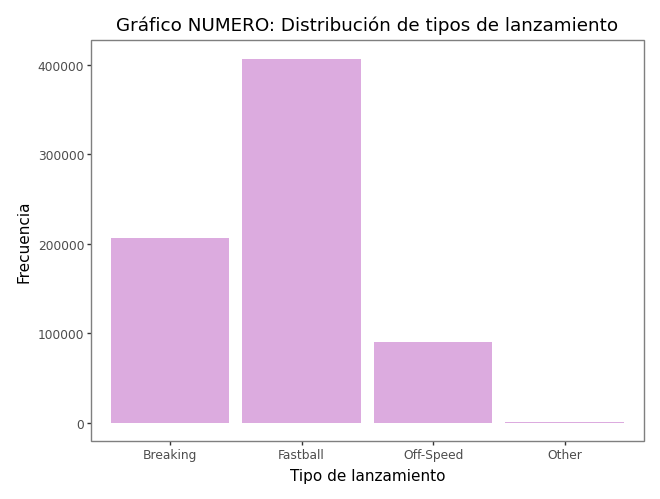

In [89]:
(
    ggplot(datos_temporada1)
    + aes(x="Lanzamiento")
    + geom_bar(fill = "#DCABDF")
    + labs(
        title="Gráfico NUMERO: Distribución de tipos de lanzamiento",
        x="Tipo de lanzamiento",
        y="Frecuencia"
    )  + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

El tipo de lanzamiento más común es *fastball*, seguido por *breaking*. bla bla bla

In [90]:
datos_temporada1["balls"].value_counts().sort("balls")

balls,count
i64,u32
0,317968
1,209035
2,119437
3,58280
4,1


Si un bateador recibe una cuarta bola, obtiene una base por bolas (walk) y el turno termina inmediatamente. Por eso no debería existir una cuenta de 4 bolas antes de un pitcheo, ya que no habría un siguiente lanzamiento. Es por esto que decidimos borrar el registro.

In [91]:
datos_temporada1 = datos_temporada1.filter(
    pl.col("balls") != 4
)

In [92]:
datos_temporada1["strikes"].value_counts()

strikes,count
i64,u32
2,208735
0,282585
1,213400


No hay strike = 3 porq si no no puede lanzar!

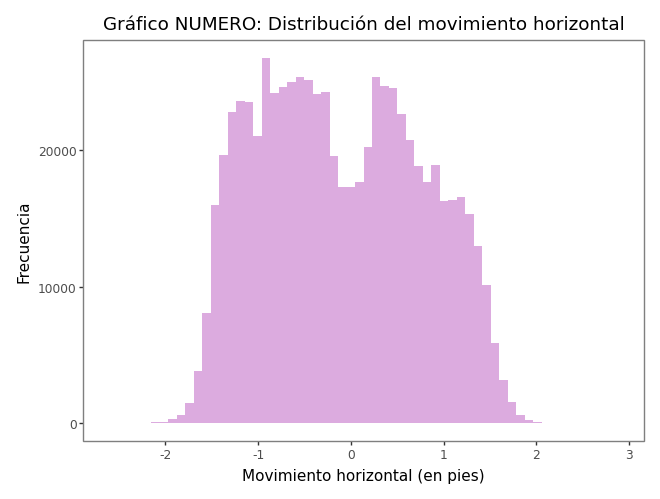

In [ ]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "pfx_x"),
                        bins = 60, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Movimiento horizontal (en pies)",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Distribución del movimiento horizontal"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

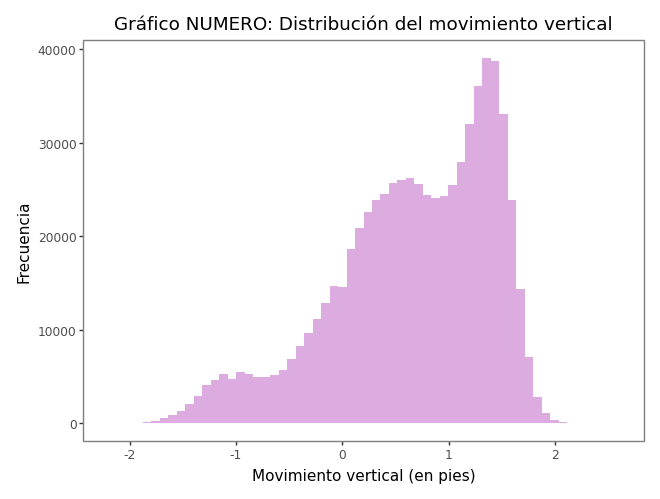

In [ ]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "pfx_z"),
                        bins = 60, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Movimiento vertical (en pies)",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Distribución del movimiento vertical"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

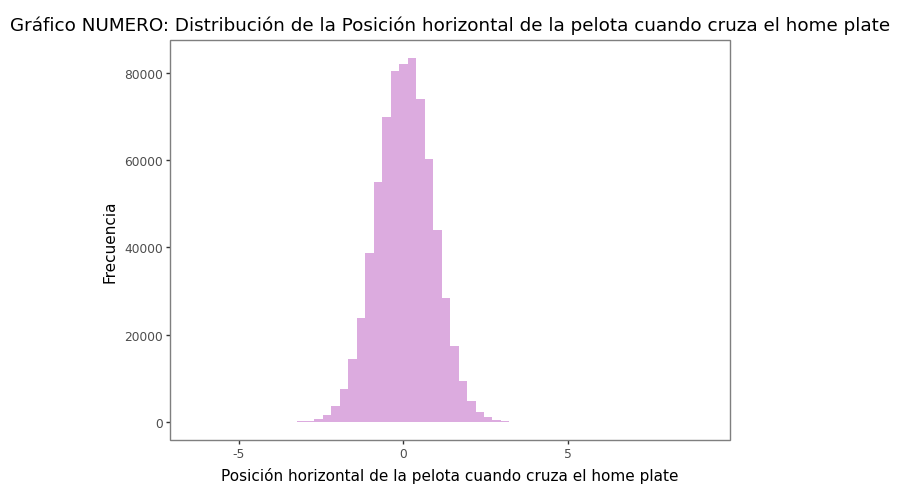

In [ ]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "plate_x"),
                        bins = 60, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Posición horizontal de la pelota cuando cruza el home plate",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Distribución de la Posición horizontal de la pelota cuando cruza el home plate"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

la mayoría pasa bien por el centro

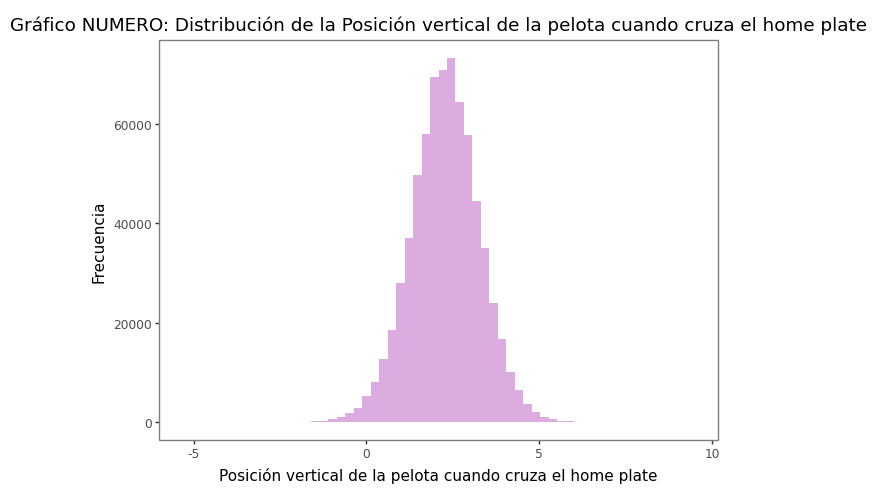

In [ ]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "plate_z"),
                        bins = 60, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Posición vertical de la pelota cuando cruza el home plate",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Distribución de la Posición vertical de la pelota cuando cruza el home plate"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

Un poco más alto que donde está el catcher

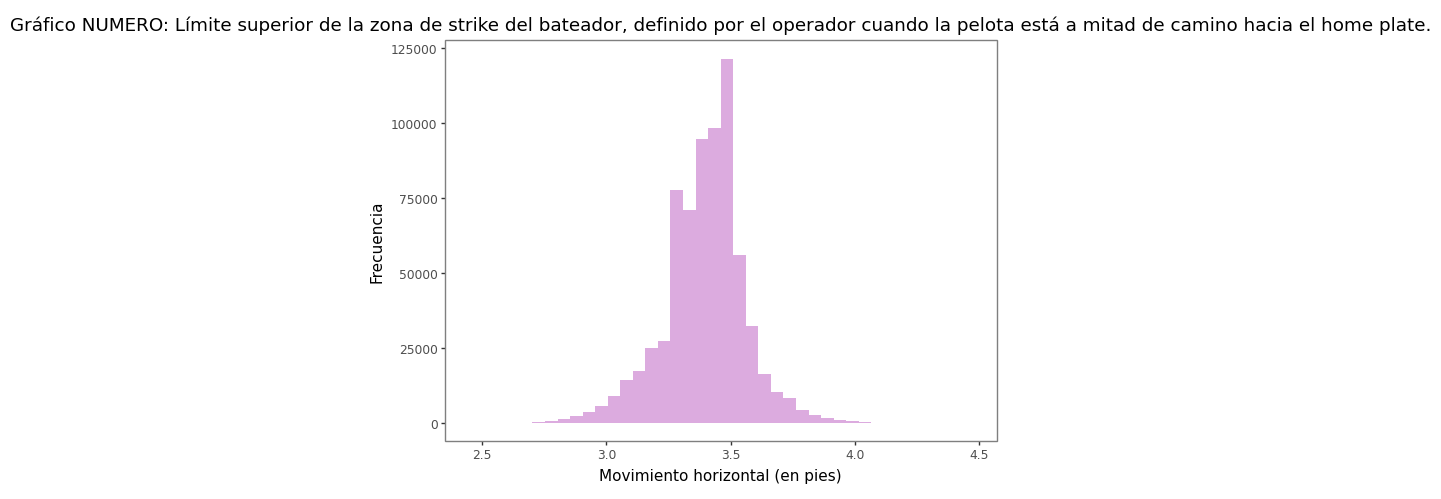

In [ ]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "sz_top"),
                        bins = 40, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Movimiento horizontal (en pies)",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Límite superior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate."
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

La mayoría de los límites sup de la zona de strike está en 3 pies

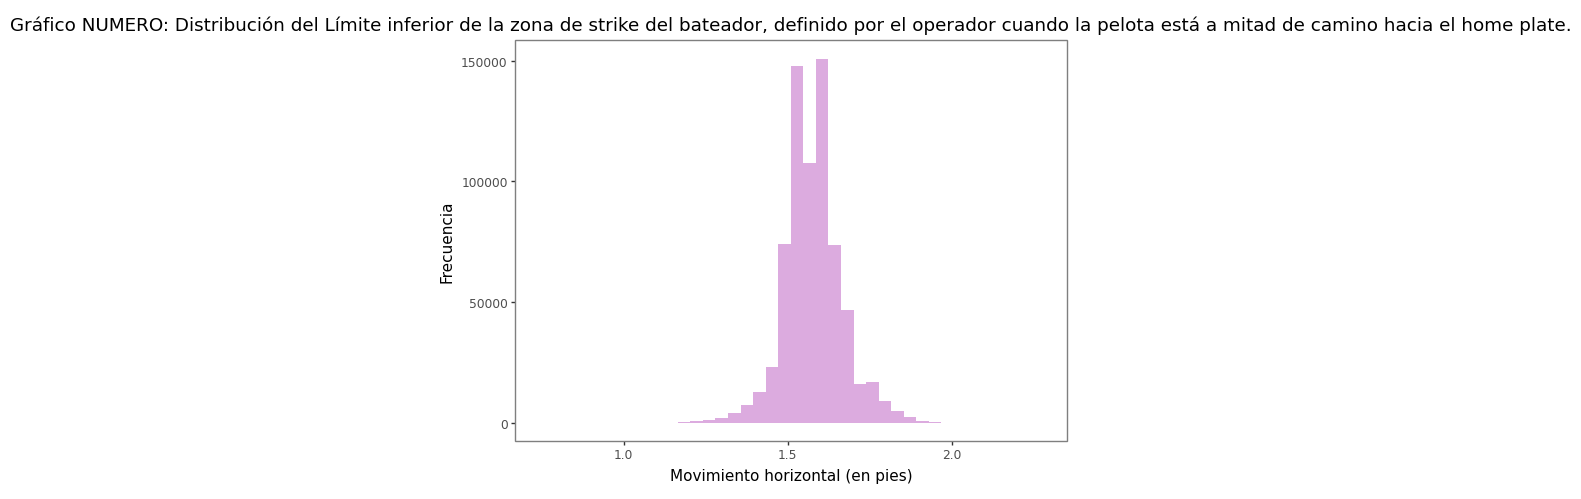

In [ ]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "sz_bot"),
                        bins = 40, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Movimiento horizontal (en pies)",
        y = "Frecuencia",
        title = "Gráfico NUMERO: Distribución del Límite inferior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate."
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

bla bla bla

## Matriz de correlación

In [93]:
continuas = [
    "release_speed",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot"
]

matriz_corr = (
    datos_temporada1
    .select(continuas)
    .to_pandas()
    .corr()
)

matriz_corr

,release_speed,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
release_speed,1.000000,-0.279239,0.727547,-0.042104,0.272504,0.032221,0.029389
pfx_x,-0.279239,1.000000,-0.203775,0.234416,-0.059033,-0.002399,-0.001394
pfx_z,0.727547,-0.203775,1.000000,-0.045404,0.345032,0.033260,0.026590
plate_x,-0.042104,0.234416,-0.045404,1.000000,-0.158949,0.002949,0.006864
plate_z,0.272504,-0.059033,0.345032,-0.158949,1.000000,0.023367,0.003074
sz_top,0.032221,-0.002399,0.033260,0.002949,0.023367,1.000000,0.779206
sz_bot,0.029389,-0.001394,0.026590,0.006864,0.003074,0.779206,1.000000


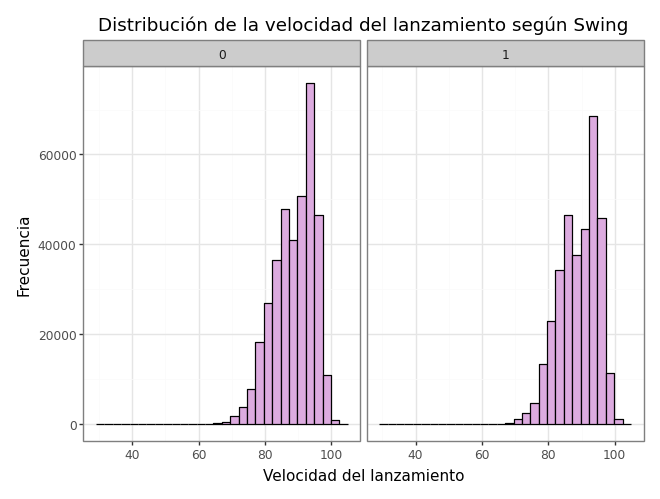

In [94]:
(
    ggplot(datos_temporada1)
    + aes(x="release_speed")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

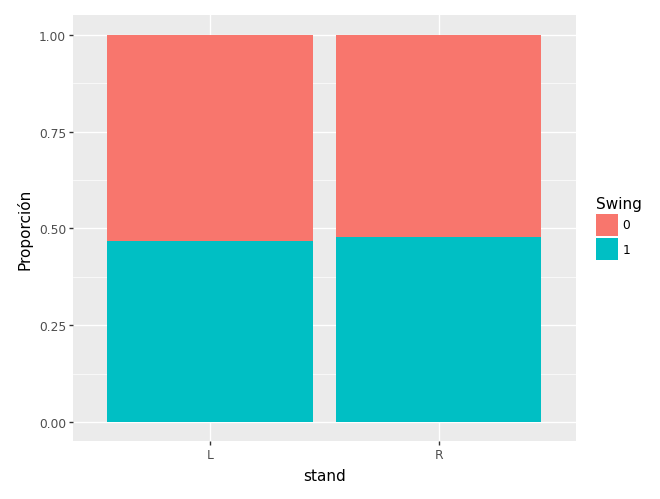

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(
        x="stand",
        fill="factor(Swing)"
    )
    + geom_bar(position="fill")
    + labs(
        y="Proporción",
        fill="Swing"
    )
)

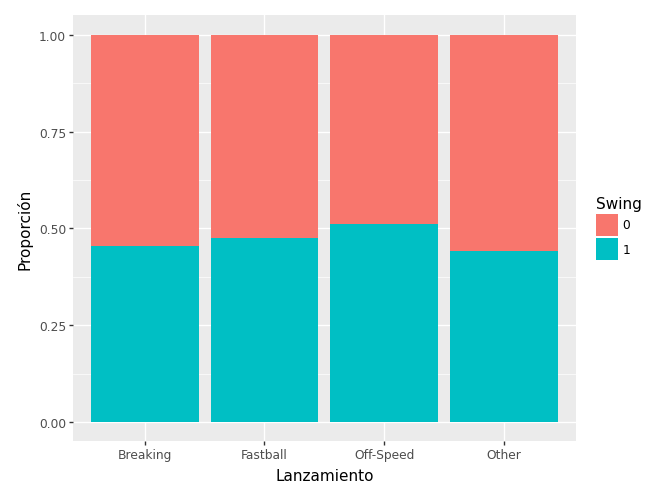

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(
        x="Lanzamiento",
        fill="factor(Swing)"
    )
    + geom_bar(position="fill")
    + labs(
        y="Proporción",
        fill="Swing"
    )
)

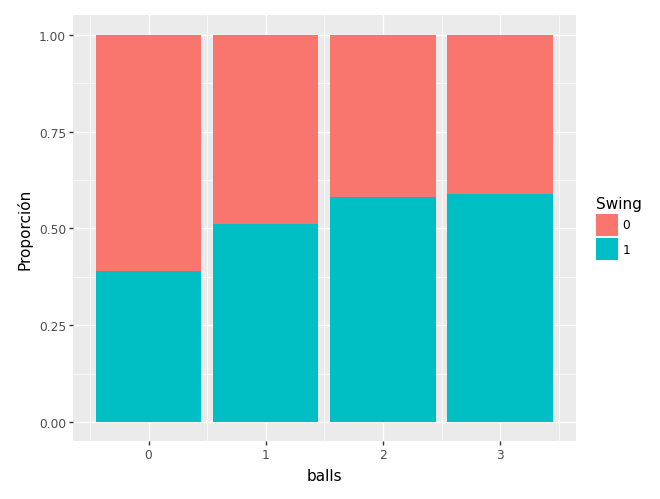

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(
        x="balls",
        fill="factor(Swing)"
    )
    + geom_bar(position="fill")
    + labs(
        y="Proporción",
        fill="Swing"
    )
)

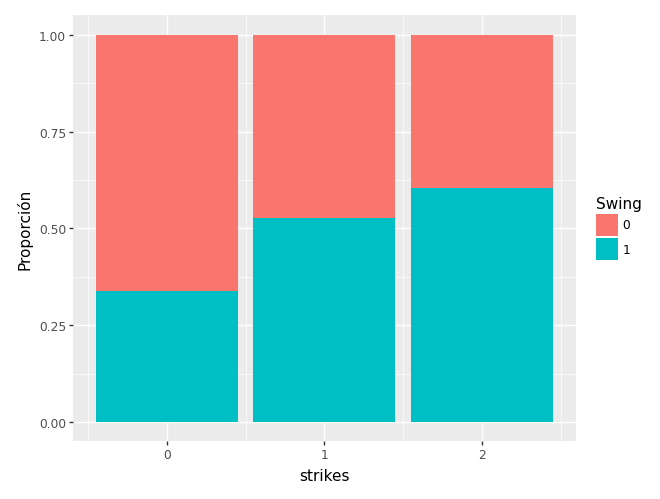

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(
        x="strikes",
        fill="factor(Swing)"
    )
    + geom_bar(position="fill")
    + labs(
        y="Proporción",
        fill="Swing"
    )
)

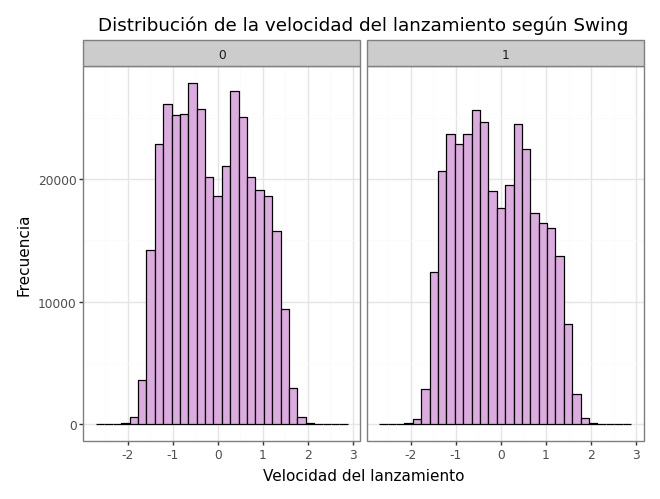

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(x="pfx_x")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

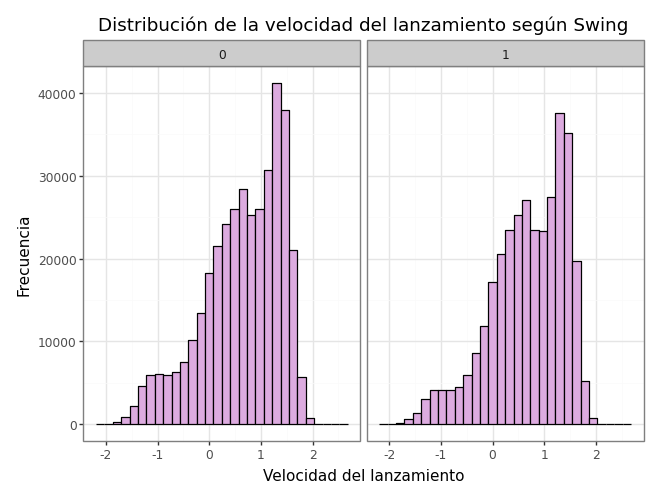

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(x="pfx_z")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

In [ ]:
datos_temporada1["Swing"].value_counts()

Swing,count
i32,u32
1,334472
0,370248


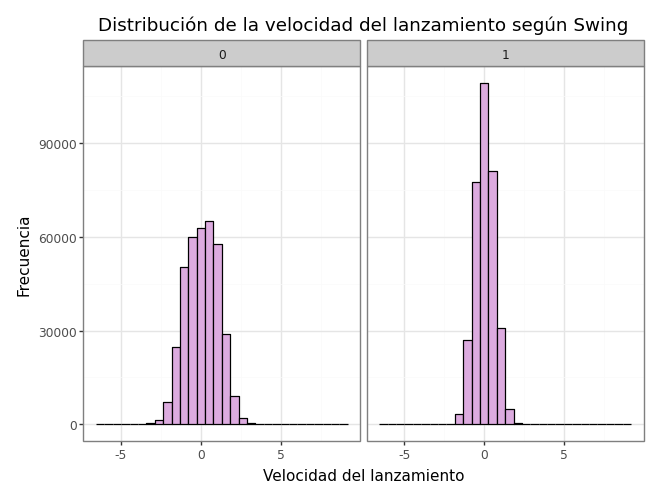

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(x="plate_x")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

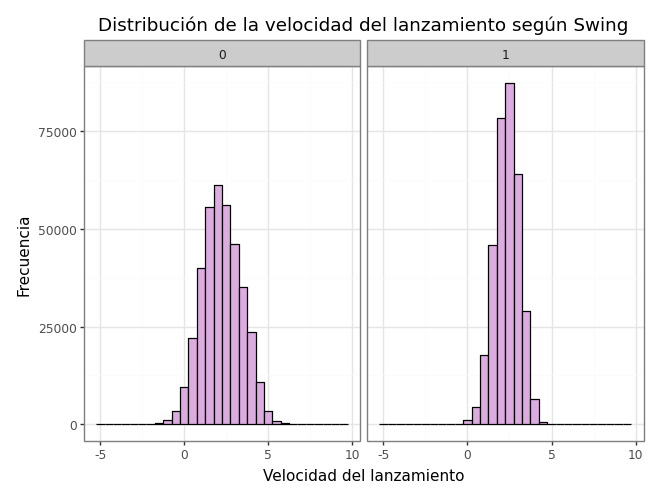

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(x="plate_z")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

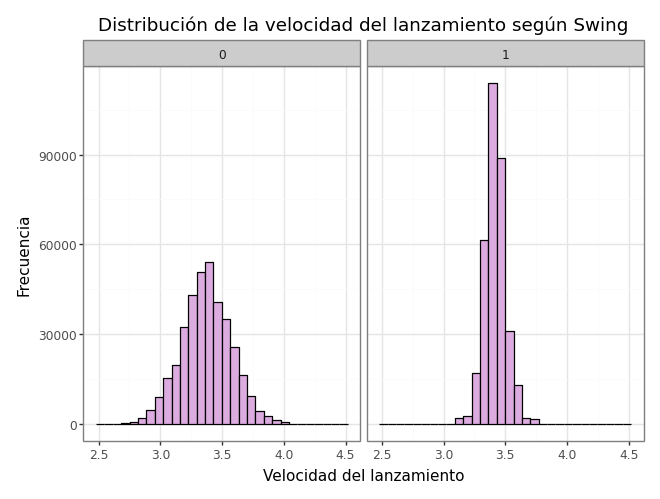

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(x="sz_top")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

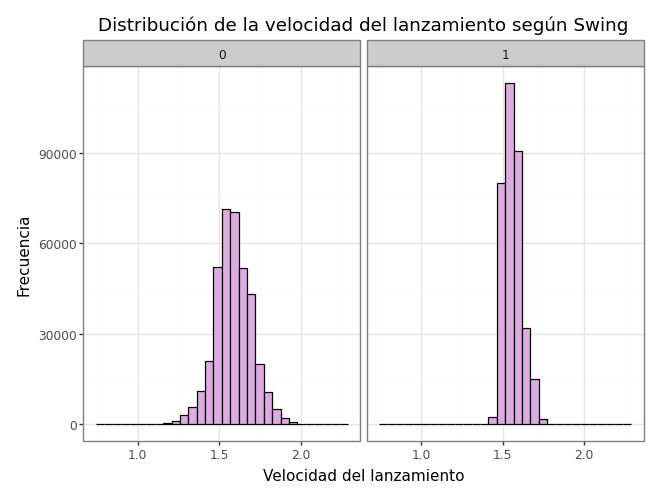

In [ ]:
(
    ggplot(datos_temporada1)
    + aes(x="sz_bot")
    + geom_histogram(
        bins=30,
        fill="#DCABDF",
        color="black"
    )
    + facet_wrap("~Swing")
    + labs(
        x="Velocidad del lanzamiento",
        y="Frecuencia",
        title="Distribución de la velocidad del lanzamiento según Swing"
    )
    + theme_bw()
)

Las variables: balls, strikes, (decidir lanzamiento), plate_x, plate_z, sz_top, sz_bot las usamos para una regresión logística

Guardamos los datos

In [98]:
datos_temporada1.write_parquet(ROOT / "Datos/datos_temporada1.parquet")